# **Astronomy 101 Week 1**

# Galaxy Survey Assignment

## About this notebook

In this notebook you will work with a dataset of 5,000 simulated galaxies. Your job is to
analyse the dataset by writing Python code using Pandas, NumPy, and Matplotlib.

The exercises start simple and gradually get harder. By the end you will have built
real data analysis skills that work on any dataset — not just astronomy.

---

## The dataset

The dataset is generated inside the notebook itself. It has 5,000 rows and 5 columns:

| Column | Type | Description |
|---|---|---|
| `galaxy_id` | string | Unique identifier for each galaxy, e.g. `GAL_00042` |
| `redshift` | float | Measure of how far away the galaxy is. Higher value means farther. |
| `stellar_mass` | float | Total mass of all stars in the galaxy, in log base-10 solar masses. |
| `star_formation_rate` | float | How many new stars the galaxy forms per year, in solar masses per year. About 3% of values are missing. |
| `morphology` | string | Visual shape of the galaxy — Elliptical, Spiral, Lenticular, or Irregular. |

---

![Galaxy Survey](https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/NGC_4414_%28NASA-med%29.jpg/1280px-NGC_4414_%28NASA-med%29.jpg)

## How each exercise is structured

Every exercise follows the same three-step pattern:

**Step 1 — Read the explanation.**
Before each exercise there is a short note explaining the concept and what you need to do.

**Step 2 — Write your code.**
Each exercise has a code cell with a comment that says `# YOUR CODE HERE`.
That is the only cell you should edit.

**Step 3 — Run the grader.**
Below every code cell there is a grader cell. Run it after writing your answer.
If your answer is correct it will print a confirmation message.
If something is wrong it will tell you exactly what the issue is.

---

## How to get started

**1. Open your personal copy**

Click the link below to open the notebook in Google Colab:
https://colab.research.google.com/drive/1TMEWLkX_CKyG5EeCCwjXskLidoTfA4a9?usp=sharing

Once it opens, go to **File → Save a copy in Drive.**
This saves a personal copy to your Google Drive. Work only on your copy — not the original.

**2. Complete the exercises**

Run every cell from top to bottom. Do not skip cells — later exercises depend on
variables created in earlier ones. Only edit cells marked `# YOUR CODE HERE`.
Do not change the grader cells.

**3. Make sure all graders pass**

Before submitting, scroll through the notebook and confirm every grader cell
shows a confirmation message. If any grader is still showing an error, go back and fix it.

**4. Share your notebook**

In Colab, click **Share** in the top-right corner.
Under General access, change it to **Anyone with the link** and set the role to **Viewer.**
Then click **Copy link.**

**5. Submit your work**

Paste the copied link into the submission form at the link below:
https://forms.gle/c91R5G9Hej45oxeb9

Make sure you submit before the deadline. Late submissions will not be accepted.

---

## Important rules

- Run the Setup cell first. It generates the dataset that all exercises depend on.
- Run cells in order from top to bottom.
- Only edit cells that say `# YOUR CODE HERE`.
- Do not modify or delete the grader cells.
- Before submitting, make sure the notebook is shared with "Anyone with the link" access,
  otherwise your submission cannot be reviewed.

## Setup — Run this first

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate the galaxy survey dataset
rng = np.random.default_rng(42)
N = 5_000

morphologies = rng.choice(
    ['Elliptical', 'Spiral', 'Lenticular', 'Irregular'],
    size=N, p=[0.30, 0.45, 0.15, 0.10]
)

mass_mu  = {'Elliptical': 11.2, 'Spiral': 10.5, 'Lenticular': 10.9, 'Irregular': 9.8}
mass_sig = {'Elliptical': 0.4,  'Spiral': 0.5,  'Lenticular': 0.4,  'Irregular': 0.5}
stellar_mass = np.array([rng.normal(mass_mu[m], mass_sig[m]) for m in morphologies]).clip(8.0, 12.5)

redshift = rng.exponential(scale=0.4, size=N).clip(0.01, 3.0)

sfr_suppress = np.where(morphologies == 'Elliptical', 0.05,
               np.where(morphologies == 'Lenticular', 0.3, 1.0))
star_formation_rate = (10 ** (stellar_mass - 10.5) * rng.lognormal(0, 0.5, N) * sfr_suppress).clip(0, 500)
star_formation_rate[rng.random(N) < 0.03] = np.nan  # ~3% missing

df = pd.DataFrame({
    'galaxy_id':           [f'GAL_{i:05d}' for i in range(1, N + 1)],
    'redshift':            np.round(redshift, 4),
    'stellar_mass':        np.round(stellar_mass, 4),
    'star_formation_rate': np.round(star_formation_rate, 3),
    'morphology':          morphologies
})

print("Dataset ready!", df.shape)
df.head()


Dataset ready! (5000, 5)


,galaxy_id,redshift,stellar_mass,star_formation_rate,morphology
0,GAL_00001,0.0713,10.4604,0.305,Lenticular
1,GAL_00002,0.4270,10.2293,NaN,Spiral
2,GAL_00003,0.0100,11.0088,1.568,Lenticular
3,GAL_00004,0.2476,10.1858,0.805,Spiral
4,GAL_00005,0.7964,11.0887,0.229,Elliptical


---
## Section 1 — DataFrame Basics

### Exercise 1 — Inspect the dataset

**Concept:** Two essential first steps with any dataset:
- `df.shape` → returns `(rows, columns)` as a tuple
- `df.describe()` → summary statistics (mean, std, min, max…) for all numeric columns

**Task:** Print the shape of `df`, then display its summary statistics.


In [ ]:
# Exercise 1
# YOUR CODE HERE
df.shape
df.describe()

,redshift,stellar_mass,star_formation_rate
count,5000.000000,5000.000000,4838.000000
mean,0.405376,10.705653,1.388291
std,0.404749,0.623941,3.223421
min,0.010000,8.168400,0.004000
25%,0.116875,10.315125,0.208250
50%,0.279100,10.765850,0.532000
75%,0.562950,11.149050,1.378750
max,3.000000,12.500000,72.061000


In [ ]:
# Grader — Exercise 1
assert df.shape == (5000, 5), "Shape should be (5000, 5)"
assert 'stellar_mass' in df.describe().columns, "describe() should include stellar_mass"
print("Passed! Dataset has", df.shape[0], "galaxies and", df.shape[1], "columns.")


Passed! Dataset has 5000 galaxies and 5 columns.


### Exercise 2 — Select columns

**Concept:** Select specific columns using a list of column names:
```python
df[['col1', 'col2']]   # returns a DataFrame with only those columns
```

**Task:** Create a new DataFrame called `mass_morph` with only the `stellar_mass` and `morphology` columns.


In [ ]:
# Exercise 2
mass_morph = df[['stellar_mass', 'morphology']]  # replace with your code

In [ ]:
# Grader — Exercise 2
assert list(mass_morph.columns) == ['stellar_mass', 'morphology'],     f"Columns should be ['stellar_mass', 'morphology'], got {list(mass_morph.columns)}"
assert mass_morph.shape == (5000, 2), f"Shape should be (5000, 2), got {mass_morph.shape}"
print("Passed! mass_morph shape:", mass_morph.shape)

Passed! mass_morph shape: (5000, 2)


### Exercise 3 — Filter rows

**Concept:** Use boolean conditions to filter rows:
```python
df[df['col'] > value]                                    # single condition
df[(df['col1'] == 'X') & (df['col2'] < 10)]             # AND  — wrap each in ()
```

**Task:** Filter `df` to keep only **Spiral** galaxies with `redshift < 0.5`. Store in `nearby_spirals`.


In [ ]:
# Exercise 3
nearby_spirals = df[(df['morphology'] == 'Spiral') & (df['redshift'] < 0.5)]  # replace with your code


In [ ]:
# Grader — Exercise 3
assert (nearby_spirals['morphology'] == 'Spiral').all(), "All rows must be Spiral"
assert (nearby_spirals['redshift'] < 0.5).all(), "All rows must have redshift < 0.5"
print(f"Passed! Found {len(nearby_spirals)} nearby Spiral galaxies.")


Passed! Found 1580 nearby Spiral galaxies.


### Exercise 4 — Add a new column

**Concept:** Create a new column directly from existing columns without using a loop:
```python
df['new_col'] = df['existing_col'] * 2
```

**Task:** The `stellar_mass` values are in log₁₀ scale. Create a new column `mass_linear` that stores the actual stellar mass by calculating:
`mass_linear = 10 ** stellar_mass`


In [ ]:
# Exercise 4
# YOUR CODE HERE
df['mass_linear'] = 10 ** df['stellar_mass']

In [ ]:
# Grader — Exercise 4
assert 'mass_linear' in df.columns, "Column 'mass_linear' not found"
assert np.allclose(df['mass_linear'], 10 ** df['stellar_mass'], rtol=1e-5), "Values are incorrect"
print(f"Passed! mass_linear range: {df['mass_linear'].min():.2e} — {df['mass_linear'].max():.2e} M☉")


Passed! mass_linear range: 1.47e+08 — 3.16e+12 M☉


### Exercise 5 — Sort and slice

**Concept:**
```python
df.sort_values('col', ascending=False)   # sort descending
df.sort_values('col').head(10)           # sort then take top 10
```

**Task:** Find the **top 10 most massive galaxies** (by `stellar_mass`). Store in `top10_massive`.


In [ ]:
# Exercise 5
top10_massive = df.sort_values('stellar_mass', ascending=False).head(10)  # replace with your code


In [ ]:
# Grader — Exercise 5
assert len(top10_massive) == 10, f"Should have 10 rows, got {len(top10_massive)}"
assert (np.diff(top10_massive['stellar_mass'].values) <= 0).all(), "Must be sorted descending"
print("Passed! Most massive galaxy:", top10_massive.iloc[0]['galaxy_id'],
      "| log M* =", round(top10_massive.iloc[0]['stellar_mass'], 3))


Passed! Most massive galaxy: GAL_03213 | log M* = 12.5


### Exercise 6 — GroupBy

**Concept:** Split the data into groups, apply a function, combine results:
```python
df.groupby('category')['value'].mean()    # mean per group → Series
df.groupby('category').size()             # count per group
```

**Task:** Compute the **mean stellar mass per morphology type**. Store as `mean_mass_by_morph`. Print it sorted descending.


In [ ]:
# Exercise 6
mean_mass_by_morph = df.groupby('morphology')['stellar_mass'].mean()  # replace with your code


In [ ]:
# Grader — Exercise 6
assert set(mean_mass_by_morph.index) == {'Elliptical','Spiral','Lenticular','Irregular'},     "Index should be the four morphology types"
expected = df[df['morphology']=='Elliptical']['stellar_mass'].mean()
assert abs(mean_mass_by_morph['Elliptical'] - expected) < 1e-6, "Elliptical mean is wrong"
print("Passed!")
print(mean_mass_by_morph.sort_values(ascending=False).round(4))


Passed!
morphology
Elliptical    11.1966
Lenticular    10.8909
Spiral        10.4981
Irregular      9.8248
Name: stellar_mass, dtype: float64


### Exercise 7 — Handle missing values

**Concept:**
```python
df['col'].isnull().sum()        # count missing values
df['col'].fillna(value)         # fill NaN with a value
df.copy()                       # make a copy so the original is unchanged
```

**Task:**
1. Count missing `star_formation_rate` values → store as `n_missing`
2. Create `df_filled` — a copy of `df` where missing SFR values are replaced with **0**


In [ ]:
# Exercise 7
n_missing = df['star_formation_rate'].isnull().sum() # replace with your code
df_filled = df.copy()  # replace with your code
df_filled['star_formation_rate'] = df_filled['star_formation_rate'].fillna(0)

In [ ]:
# Grader — Exercise 7
assert isinstance(n_missing, (int, np.integer)) and n_missing > 0,     "n_missing should be a positive integer"
assert df_filled['star_formation_rate'].isnull().sum() == 0, "df_filled still has NaN values"
assert df['star_formation_rate'].isnull().sum() == n_missing, "Don't modify the original df"
print(f"Passed! Found and filled {n_missing} missing SFR values.")


Passed! Found and filled 162 missing SFR values.


---
## Section 2 — Visualisation with Matplotlib

### Exercise 8 — Your first plot: histogram

A histogram shows the distribution of a single numeric column — how many values fall in each range.

```python
plt.figure(figsize=(8, 4))        # set figure size
plt.hist(data, bins=30)           # draw the histogram
plt.xlabel('X label')             # label the x axis
plt.ylabel('Y label')             # label the y axis
plt.title('Chart title')          # add a title
plt.show()                        # display it
```

**Task:** Plot a histogram of `stellar_mass` with **40 bins**.
Label the x-axis `"Stellar Mass (log M☉)"`, y-axis `"Number of Galaxies"`, and title `"Distribution of Stellar Mass"`.


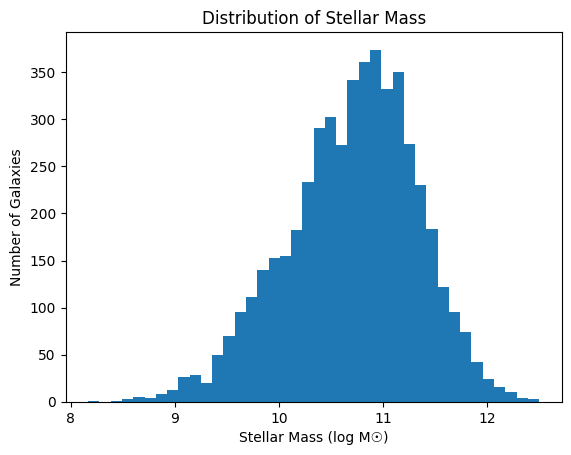

In [ ]:
# Exercise 8 (Don't write plt.show())
# YOUR CODE HERE
plt.hist(stellar_mass, bins=40)
plt.xlabel('Stellar Mass (log M☉)')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Stellar Mass')
# ----- DO NOT MODIFY BELOW -----
_hist_ax = plt.gca()

In [ ]:
# Grader — Exercise 8
assert '_hist_ax' in globals(), "Histogram axis not found."

assert len(_hist_ax.patches) == 40, (
    f"Expected 40 bins, found {len(_hist_ax.patches)}"
)

assert _hist_ax.get_xlabel() == "Stellar Mass (log M☉)", (
    "Incorrect x-axis label"
)

assert _hist_ax.get_ylabel() == "Number of Galaxies", (
    "Incorrect y-axis label"
)

assert _hist_ax.get_title() == "Distribution of Stellar Mass", (
    "Incorrect title"
)

print("Passed! Histogram looks good.")


Passed! Histogram looks good.


### Exercise 9 — Bar chart

A bar chart compares a value across categories.

```python
plt.bar(categories, values, color='steelblue')
```

You already computed `mean_mass_by_morph` in Exercise 6 — use it here.

**Task:** Plot a **bar chart** showing mean stellar mass for each morphology type.
Sort the bars from highest to lowest mass. Add axis labels and a title.


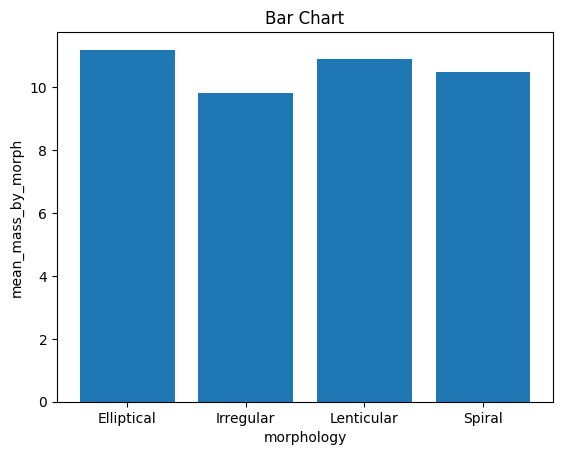

In [ ]:
# Exercise 9 (Don't write plt.show())
# YOUR CODE HERE
plt.bar(mean_mass_by_morph.index, mean_mass_by_morph)
plt.xlabel('morphology')
plt.ylabel('mean_mass_by_morph')
plt.title('Bar Chart')
# DO NOT MODIFY
_bar_ax = plt.gca()

In [ ]:
# Grader — Exercise 9

assert '_bar_ax' in globals(), "Bar chart axis not found."

assert len(_bar_ax.patches) == 4, (
    f"Expected 4 bars (one per morphology), found {len(_bar_ax.patches)}"
)

assert _bar_ax.get_xlabel() != '' or _bar_ax.get_ylabel() != '', (
    "Add at least one axis label"
)

assert _bar_ax.get_title() != '', (
    "Title is missing"
)

print("Passed! Bar chart looks good.")


Passed! Bar chart looks good.


### Exercise 10 — Scatter plot

A scatter plot shows the relationship between two numeric columns.

```python
plt.scatter(x, y, alpha=0.3, s=10)   # alpha = transparency, s = dot size
```

**Task:** Make a scatter plot of `redshift` (x-axis) vs `stellar_mass` (y-axis).
Use `alpha=0.2` and `s=8` so the dense points don't overlap too much.
Add axis labels and a title.


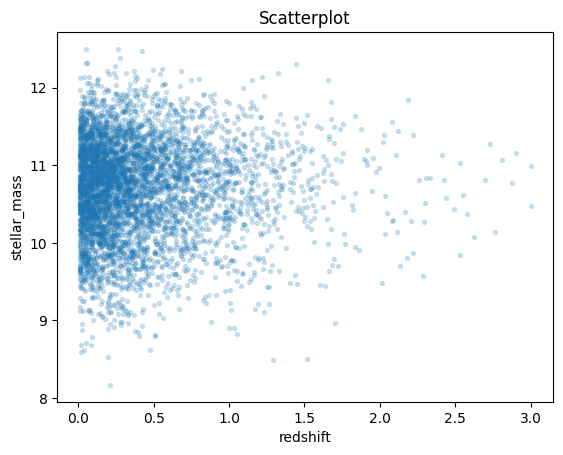

In [ ]:
# Exercise 10 (Don't write plt.show())
# YOUR CODE HERE
plt.scatter(redshift, stellar_mass, alpha=0.2, s=8)
plt.xlabel('redshift')
plt.ylabel('stellar_mass')
plt.title('Scatterplot')
# DO NOT MODIFY
_scatter_ax = plt.gca()

In [ ]:
# Grader — Exercise 10

assert '_scatter_ax' in globals(), "Scatter plot axis not found."

assert len(_scatter_ax.collections) > 0, (
    "No scatter points found — did you call plt.scatter()?"
)

assert _scatter_ax.get_xlabel() != '', (
    "X-axis label is missing"
)

assert _scatter_ax.get_ylabel() != '', (
    "Y-axis label is missing"
)

assert _scatter_ax.get_title() != '', (
    "Title is missing"
)

print("Passed! Scatter plot looks good.")

Passed! Scatter plot looks good.


### Exercise 11 — Subplots (side by side)

`plt.subplots` lets you put multiple charts in one figure:

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))   # 1 row, 2 columns

axes[0].hist(data, bins=30)
axes[0].set_title('Left chart')

axes[1].bar(categories, values)
axes[1].set_title('Right chart')

plt.tight_layout()   # prevents labels overlapping
plt.show()
```

**Task:** Create a **1×2 subplot figure**:
- Left: histogram of `redshift` (30 bins)
- Right: histogram of `star_formation_rate` (30 bins, ignore NaN with `dropna()`)

Add a title to each panel and call `plt.tight_layout()`.


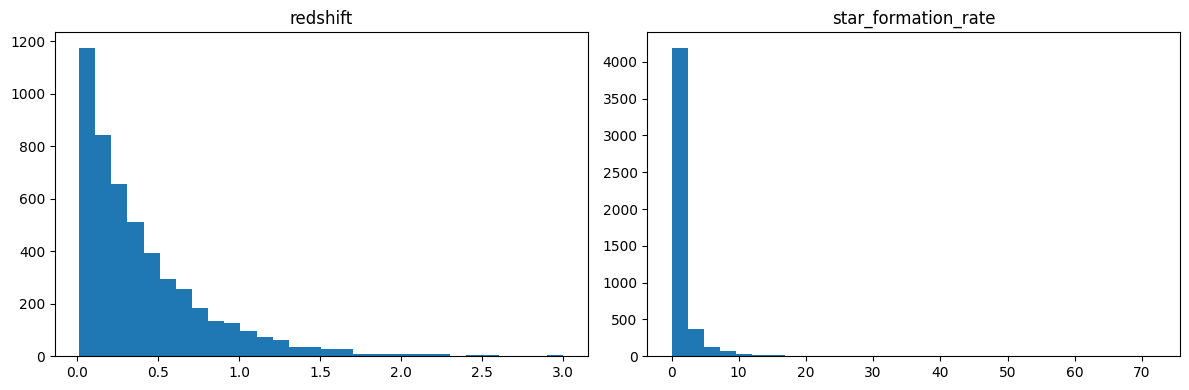

In [ ]:
# Exercise 11 (Don't write plt.show())
# YOUR CODE HERE
fig, axesE = plt.subplots(1, 2, figsize=(12, 4))
axesE[0].hist(redshift, bins=30)
axesE[0].set_title('redshift')

axesE[1].hist(star_formation_rate, bins=30)
axesE[1].set_title('star_formation_rate')

plt.tight_layout()
# DO NOT MODIFY
_subplot_axes = axesE

In [ ]:
# Grader — Exercise 11

assert '_subplot_axes' in globals(), "Subplot axes not found."

axes = _subplot_axes

assert len(axes) == 2, (
    f"Expected 2 subplots, found {len(axes)}"
)

assert len(axes[0].patches) == 30, (
    f"Left panel: expected 30 bins, got {len(axes[0].patches)}"
)

assert len(axes[1].patches) == 30, (
    f"Right panel: expected 30 bins, got {len(axes[1].patches)}"
)

assert axes[0].get_title() != '', (
    "Left panel needs a title"
)

assert axes[1].get_title() != '', (
    "Right panel needs a title"
)

print("Passed! Subplots look good.")

Passed! Subplots look good.


### Exercise 12 — Box plot

A box plot shows the spread of a numeric column across categories:
- The box covers the middle 50% of values
- The line inside is the median
- The whiskers show the overall range

```python
groups = [df[df['category'] == c]['value'] for c in category_list]
plt.boxplot(groups, labels=category_list)
```

**Task:** Draw a box plot of `stellar_mass` for each of the four morphology types.
Label the x-axis `"Morphology"`, y-axis `"Stellar Mass (log M☉)"`, and add a title.


/tmp/ipykernel_4675/165017781.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=mean_mass_by_morph.index)


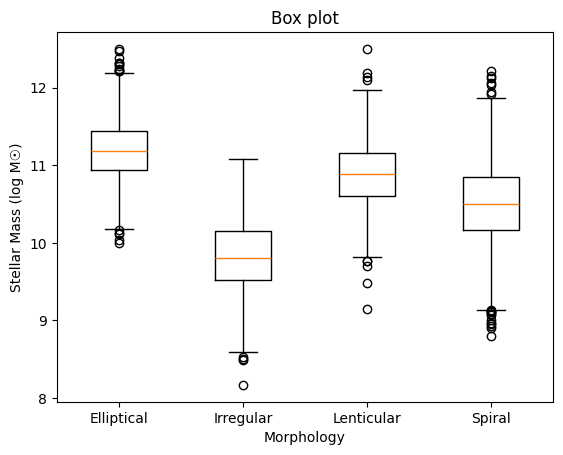

In [ ]:
# Exercise 12 (Don't write plt.show())
# YOUR CODE HERE
groups = [df[df['morphology'] == c]['stellar_mass'] for c in mean_mass_by_morph.index]
plt.boxplot(groups, labels=mean_mass_by_morph.index)
plt.xlabel('Morphology')
plt.ylabel('Stellar Mass (log M☉)')
plt.title('Box plot')
# DO NOT MODIFY
_box_ax = plt.gca()

In [ ]:
# Grader — Exercise 12

assert '_box_ax' in globals(), "Box plot axis not found."

ax = _box_ax

# Boxplots create many lines (medians, whiskers, caps, etc.)
assert len(ax.lines) >= 20, (
    "Expected box plots for 4 morphology groups"
)

assert ax.get_xlabel() == "Morphology", (
    "Incorrect x-axis label"
)

assert ax.get_ylabel() == "Stellar Mass (log M☉)", (
    "Incorrect y-axis label"
)

assert ax.get_title() != '', (
    "Title is missing"
)

assert len(ax.get_xticklabels()) == 4, (
    f"Expected 4 morphology labels, found {len(ax.get_xticklabels())}"
)

print("Passed! Box plot looks good.")

Passed! Box plot looks good.


---
## Completed exercises

Run the cell below to see your progress.


In [ ]:
exercises = {
    'Ex 1  — Inspect dataset':    df.shape == (5000, 6),
    'Ex 2  — Select columns':     'mass_morph' in dir() and mass_morph is not None,
    'Ex 3  — Filter rows':        'nearby_spirals' in dir() and nearby_spirals is not None,
    'Ex 4  — Add column':         'mass_linear' in df.columns,
    'Ex 5  — Sort & slice':       'top10_massive' in dir() and top10_massive is not None,
    'Ex 6  — GroupBy mean':       'mean_mass_by_morph' in dir() and mean_mass_by_morph is not None,
    'Ex 7  — Missing values':     'df_filled' in dir() and df_filled is not None,
    'Ex 8  — Histogram':          True,  # visual check
    'Ex 9  — Bar chart':          True,
    'Ex 10 — Scatter plot':       True,
    'Ex 11 — Subplots':           True,
    'Ex 12 — Box plot':           True,
}

done = sum(v for v in exercises.values())
total = len(exercises)
print(f"Progress: {done}/{total}\n")
for name, passed in exercises.items():
    print(f"  {'Completed' if passed else 'Incomplete'} {name}")


Progress: 12/12

  Completed Ex 1  — Inspect dataset
  Completed Ex 2  — Select columns
  Completed Ex 3  — Filter rows
  Completed Ex 4  — Add column
  Completed Ex 5  — Sort & slice
  Completed Ex 6  — GroupBy mean
  Completed Ex 7  — Missing values
  Completed Ex 8  — Histogram
  Completed Ex 9  — Bar chart
  Completed Ex 10 — Scatter plot
  Completed Ex 11 — Subplots
  Completed Ex 12 — Box plot
